In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import netCDF4 as nc
import xarray as xr

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import axis_ratio_from_Q, tangential_velocity


In [2]:
def doppio(x1, y1, u1, v1, x2, y2, u2, v2, degree=3, tol=1e-8):
    x1,y1,u1,v1 = map(lambda a: np.asarray(a, float), (x1,y1,u1,v1))
    x2,y2,u2,v2 = map(lambda a: np.asarray(a, float), (x2,y2,u2,v2))

    m1 = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(u1) & np.isfinite(v1)
    m2 = np.isfinite(x2) & np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)
    x1,y1,u1,v1 = x1[m1], y1[m1], u1[m1], v1[m1]
    x2,y2,u2,v2 = x2[m2], y2[m2], u2[m2], v2[m2]

    nan2 = np.full((2, 2), np.nan)
    fail = (np.nan, np.nan, np.nan, nan2, np.nan)

    if x1.size < degree + 1 or x2.size < degree + 1:
        return fail

    # robust "common point" (floats): nearest pair within tol
    P1 = np.c_[x1, y1]
    P2 = np.c_[x2, y2]
    d2 = ((P1[:, None, :] - P2[None, :, :]) ** 2).sum(-1)
    i, j = np.unravel_index(np.argmin(d2), d2.shape)
    if d2[i, j] > tol**2:
        return fail
    center_x, center_y = P1[i]

    def root_near_mid(x, y):
        c = np.polyfit(x, y, degree)
        r = np.roots(c)
        r = r[np.isreal(r)].real
        if r.size == 0:
            return np.nan
        mid = x[x.size // 2]
        return r[np.argmin(np.abs(r - mid))]

    def tangent_fit(x, y, x0):
        c = np.polyfit(x, y, degree)
        slope = np.polyval(np.polyder(c), x0)
        intercept = np.polyval(c, x0) - slope * x0
        yhat = np.polyval(c, x)
        sst = np.sum((y - y.mean())**2)
        r2 = 1 - np.sum((y - yhat)**2)/sst if sst > 0 else 1.0
        return slope, intercept, r2

    xx = x1 - center_x
    yy = y2 - center_y

    rx = root_near_mid(xx, v1)
    ry = root_near_mid(yy, u2)
    if not (np.isfinite(rx) and np.isfinite(ry)):
        return fail

    A1, A0, r2A = tangent_fit(xx, u1, rx)
    B1, B0, r2B = tangent_fit(xx, v1, rx)
    C1, C0, r2C = tangent_fit(yy, u2, ry)
    D1, D0, r2D = tangent_fit(yy, v2, ry)

    alpha = A0 if r2A > r2C else C0
    beta  = B0 if r2B > r2D else D0
    gamma = A1 if r2A > r2D else -D1

    Aq11 = 0.5 * B1
    Aq22 = -0.5 * C1
    Aq12 = -0.5 * gamma

    denom = C1 * B1 + gamma**2
    if denom == 0 or not np.isfinite(denom):
        return fail

    xc = - (alpha * gamma + beta * C1) / denom + center_x
    yc =   (beta * gamma - alpha * B1) / denom + center_y
    w  = 2 * (Aq11 + Aq22)

    AQ = np.array([[Aq11, Aq12], [Aq12, Aq22]])
    det = AQ[0,0]*AQ[1,1] - AQ[0,1]*AQ[1,0]
    A = np.sign(Aq11) * np.sqrt(abs(det))
    Q = AQ / A if A != 0 else nan2

    return xc, yc, w, Q, A

def fit_psi_params(rho2, Qr, vt, A0=None, Rc0=None, plot=False, ax=None,
                   maxfev=10000, Rc_max=1e5, r2_flag=False,
                   rho_plot_max=None, n_curve=400):
    
    from scipy.optimize import curve_fit

    rho2 = np.asarray(rho2, float)
    Qr   = np.asarray(Qr, float)
    vt   = np.asarray(vt, float)

    m = np.isfinite(rho2) & np.isfinite(Qr) & np.isfinite(vt) & (rho2 >= 0) & (Qr != 0)
    if not np.any(m):
        return (np.nan, np.nan, np.nan, np.nan) if r2_flag else (np.nan, np.nan, np.nan)

    rho2 = rho2[m]; Qr = Qr[m]; vt = vt[m]

    # v*_t = v_t * (rho/Qr)
    rho = np.sqrt(rho2)
    vt = vt * (rho / Qr)

    def vt_model(rho2_, A, Rc):
        return 2.0 * A * np.sqrt(rho2_) * np.exp(-rho2_ / (Rc * Rc))

    # initial Rc0 from location of max |vt|
    i = np.nanargmax(np.abs(vt))
    rho_max = rho[i]
    if Rc0 is None:
        Rc0 = max(rho_max * np.sqrt(2.0), 1e-6)

    if A0 is None:
        denom = 2.0 * rho * np.exp(-rho2 / (Rc0 * Rc0))
        ok = np.abs(denom) > 0
        A0 = np.nanmedian(vt[ok] / denom[ok]) if np.any(ok) else 0.0
    if not np.isfinite(A0):
        A0 = 0.0

    try:
        popt, _ = curve_fit(
            vt_model, rho2, vt, p0=[A0, Rc0],
            bounds=([-np.inf, 1e-8], [np.inf, np.inf]),
            maxfev=maxfev
        )
        A_opt, Rc_opt = popt
    except Exception:
        A_opt, Rc_opt = A0, Rc0

    if (not np.isfinite(Rc_opt)) or (Rc_opt > Rc_max):
        A_opt, Rc_opt = A0, Rc0

    psi0_opt = -A_opt * Rc_opt**2

    vt_fit = vt_model(rho2, A_opt, Rc_opt)
    ss_res = np.sum((vt - vt_fit)**2)
    ss_tot = np.sum((vt - vt.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    if plot:
        if ax is None:
            _, ax = plt.subplots()

        if rho_plot_max is None:
            rho_plot_max = float(np.nanmax(rho)) if rho.size else Rc_opt

        r_grid = np.linspace(0.0, rho_plot_max, n_curve)
        vt_grid = vt_model(r_grid**2, A_opt, Rc_opt)

        ax.scatter(rho, np.abs(vt), s=20, marker='.', label='Observed')
        ax.plot(r_grid, np.abs(vt_grid), lw=3, label='Fit')
        ax.axvline(Rc_opt/np.sqrt(2), ls='--', lw=3, label=r'$\rho_{\max}$')

        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(r'$|v_t^\star|$')
        ax.set_title(f'A={A_opt:.4g}, Rc={Rc_opt:.4g}, psi0={psi0_opt:.4g}, R²={r2:.2f}')
        ax.legend()

    return (Rc_opt, psi0_opt, A_opt, r2) if r2_flag else (Rc_opt, psi0_opt, A_opt)
    

In [3]:
def dopioe_pipeliner(nxc, nyc, ut, vt, X_new, Y_new, r=30000.0):
    nan = (np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan)

    x = np.asarray(X_new[:, 0], float)
    y = np.asarray(Y_new[0, :], float)

    dx = np.nanmedian(np.abs(np.diff(x)))
    dy = np.nanmedian(np.abs(np.diff(y)))
    cell = np.nanmax([dx, dy])
    if not np.isfinite(cell) or cell == 0:
        return nan

    margin = int(np.ceil(r / cell))

    ic = int(np.clip(np.searchsorted(x, nxc), 1, x.size-1))
    ic -= (nxc - x[ic-1] < x[ic] - nxc)
    jc = int(np.clip(np.searchsorted(y, nyc), 1, y.size-1))
    jc -= (nyc - y[jc-1] < y[jc] - nyc)

    if ic < margin or ic >= x.size - margin or jc < margin or jc >= y.size - margin:
        return nan

    # x-transect (y = y[jc])
    i0 = np.searchsorted(x, nxc - r, side="left")
    i1 = np.searchsorted(x, nxc + r, side="right")
    x1 = x[i0:i1]
    y1 = np.full(x1.size, y[jc])
    u1 = ut[i0:i1, jc]
    v1 = vt[i0:i1, jc]

    # y-transect (x = x[ic])
    j0 = np.searchsorted(y, nyc - r, side="left")
    j1 = np.searchsorted(y, nyc + r, side="right")
    y2 = y[j0:j1]
    x2 = np.full(y2.size, x[ic])
    u2 = ut[ic, j0:j1]
    v2 = vt[ic, j0:j1]

    return x1, y1, u1, v1, x2, y2, u2, v2
    

### Satellite Data

In [4]:
ssh_path = '/srv/scratch/z5297792/ESP_Paper_Data/sat_data_IMOS_drifters.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['LONGITUDE'][:].data, ds_nc['LATITUDE'][:].data
u, v = ds_nc['UCUR'][:].data, ds_nc['VCUR'][:].data

t = pd.Timestamp("1985-01-01 00:00:00", tz="UTC") + pd.to_timedelta(ds_nc['TIME'][:].data, "D")
t = pd.DatetimeIndex(t).tz_convert(None)

u, v = np.where(np.abs(u) < 4.9, u, np.nan), np.where(np.abs(v) < 4.9, v, np.nan)

ds = xr.Dataset(
    {"u": (("time","lat","lon"), u), "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon},
)

theta_mean, phi_mean = np.float64(154.3), np.float64(-37.9)
lon2d, lat2d = np.meshgrid(lon, lat)
ds = ds.assign_coords(
    x=(("lat","lon"), (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))),
    y=(("lat","lon"), (lat2d-phi_mean)*111000),
)

t0, t1 = ds.time.to_index()[0], ds.time.to_index()[-1]
start = t0.normalize() + pd.Timedelta(hours=6) + pd.Timedelta(days=int(t0 > t0.normalize() + pd.Timedelta(hours=6)))
end   = t1.normalize() + pd.Timedelta(hours=6) - pd.Timedelta(days=int(t1 < t1.normalize() + pd.Timedelta(hours=6)))
t6am = pd.date_range(start, end, freq="1D")

ds_sat = ds.interp(time=t6am)

# Find land mask
land_mask = np.isnan(ds.u.isel(time=0)) & np.isnan(ds.v.isel(time=0))  # (lat, lon)
ds = ds.assign(land_mask=land_mask)
ds_sat = ds_sat.assign(land_mask=land_mask)

# # Time slice
ds_sat = ds_sat.sel(time=ds_sat.time <= np.datetime64('2024-01-27T06:00:00.000000000'))

ds_sat


<xarray.Dataset> Size: 3MB
Dimensions:    (time: 101, lat: 41, lon: 46)
Coordinates:
  * lat        (lat) float64 328B -42.0 -41.8 -41.6 -41.4 ... -34.4 -34.2 -34.0
  * lon        (lon) float64 368B 149.0 149.2 149.4 149.6 ... 157.6 157.8 158.0
    x          (lat, lon) float64 15kB -4.642e+05 -4.467e+05 ... 3.241e+05
    y          (lat, lon) float64 15kB -4.551e+05 -4.551e+05 ... 4.329e+05
  * time       (time) datetime64[ns] 808B 2023-10-19T06:00:00 ... 2024-01-27T...
Data variables:
    u          (time, lat, lon) float64 2MB -0.165 -0.2501 ... 0.2664 0.3238
    v          (time, lat, lon) float64 2MB -0.1421 -0.1373 ... -0.4036 -0.314
    land_mask  (lat, lon) bool 2kB False False False False ... False False False

In [5]:
xc_pre, yc_pre = 0.0, 0.0
rows = []
xyuv_rows = []

X = ds_sat.x.values
Y = ds_sat.y.values

for time in ds_sat.time.values:
    ut = ds_sat.u.sel(time=time).values
    vt = ds_sat.v.sel(time=time).values

    x1,y1,u1,v1,x2,y2,u2,v2 = dopioe_pipeliner(xc_pre, yc_pre, ut.T, vt.T, X.T, Y.T, r=50_000)
    xc, yc, w, Q, A = doppio(x1,y1,u1,v1, x2,y2,u2,v2)

    ok = (np.isfinite(xc) and np.isfinite(yc) and
          (np.hypot(xc-xc_pre, yc-yc_pre) < 100_000) and (w < 0))

    if not ok:
        break

    rows.append(dict(xc=xc, yc=yc, w=w, Q=Q, A=A, time=time))
    xc_pre, yc_pre = xc, yc

    xi = np.concatenate([x1, x2])
    yi = np.concatenate([y1, y2])
    ui = np.concatenate([u1, u2])
    vi = np.concatenate([v1, v2])

    xyuv_rows.append(pd.DataFrame({
        "time": time,
        "core": "inner",
        "xi": xi, "yi": yi, "ui": ui, "vi": vi
    }))

df_res = pd.DataFrame(rows, columns=["xc","yc","w","Q","A","time"])
df_res["alpha"] = [axis_ratio_from_Q(Q) for Q in df_res["Q"].to_list()]

df_xyuv = pd.concat(xyuv_rows, ignore_index=True) if xyuv_rows else pd.DataFrame(
    columns=["time","core","xi","yi","ui","vi"]
)

df_res


,xc,yc,w,Q,A,time,alpha
0,4193.689389,4401.502757,-0.000034,"[[1.2204584369358924, 0.00955384510611513], [0...",-0.000008,2023-10-19 06:00:00,1.220686
1,4149.924800,4200.250483,-0.000035,"[[1.2268136344951672, 0.02527570148295296], [0...",-0.000009,2023-10-20 06:00:00,1.228362
2,3595.225376,4499.914019,-0.000036,"[[1.2193540416007598, 0.01738799276173218], [0...",-0.000009,2023-10-21 06:00:00,1.220110
3,2431.948692,5321.980911,-0.000034,"[[1.2177165995743318, 0.007347480044136685], [...",-0.000008,2023-10-22 06:00:00,1.217853
4,982.616545,5652.043129,-0.000032,"[[1.2228262865919268, 0.017546568770867892], [...",-0.000008,2023-10-23 06:00:00,1.223585
...,...,...,...,...,...,...,...
96,-266719.734674,118548.547891,-0.000022,"[[0.8761191837990826, -0.35604564329966915], [...",-0.000005,2024-01-23 06:00:00,1.491942
97,-271473.086131,116957.190514,-0.000023,"[[0.8476725343648427, -0.33888896792651385], [...",-0.000005,2024-01-24 06:00:00,1.493117
98,-279706.207006,112928.557936,-0.000022,"[[0.8453647786032502, -0.3721619634955894], [-...",-0.000005,2024-01-25 06:00:00,1.544788
99,-287163.843631,110593.495745,-0.000021,"[[0.799203334562713, -0.31281735512116443], [-...",-0.000005,2024-01-26 06:00:00,1.511136


In [6]:
# xc_pre, yc_pre = 0.0, 0.0
# rows = []

# X  = ds_sat.x.values
# Y  = ds_sat.y.values
# for time in ds_sat.time.values:
#     ut = ds_sat.u.sel(time=time).values
#     vt = ds_sat.v.sel(time=time).values

#     x1,y1,u1,v1,x2,y2,u2,v2 = dopioe_pipeliner(xc_pre, yc_pre, ut.T, vt.T, X.T, Y.T, r=50_000)
#     xc, yc, w, Q, A = doppio(x1,y1,u1,v1, x2,y2,u2,v2)

#     if np.isfinite(xc) and np.isfinite(yc) and (np.hypot(xc-xc_pre, yc-yc_pre) < 100_000) and (w < 0):
#         rows.append(dict(xc=xc, yc=yc, w=w, Q=Q, A=A, time=time))
#         xc_pre, yc_pre = xc, yc
#     else:
#         break 

# df_res = pd.DataFrame(rows, columns=["xc","yc","w","Q","A","time"])
# df_res["alpha"] = [axis_ratio_from_Q(Q) for Q in df_res["Q"].to_list()]
# df_res


(np.float64(-304902.4685384417),
 np.float64(18912.554052111715),
 np.float64(-10717.822847705713),
 np.float64(165456.7763576851))

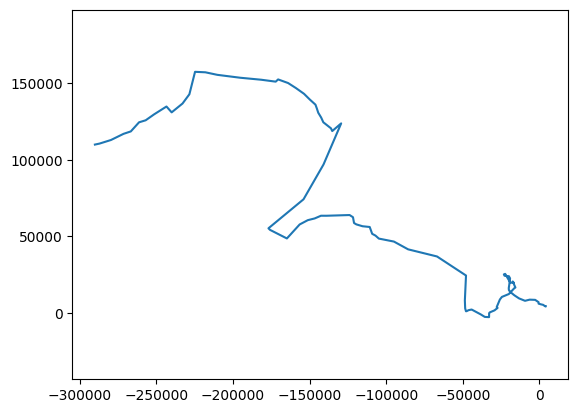

In [7]:
plt.plot(df_res.xc, df_res.yc)
plt.axis('equal')


,xc,yc,w,Q,A,time,alpha,Rc,psi0,A_opt
0,4193.689389,4401.502757,-0.000034,"[[1.2204584369358924, 0.00955384510611513], [0...",-0.000008,2023-10-19 06:00:00,1.220686,93024.666470,65726.558539,-0.000008
1,4149.924800,4200.250483,-0.000035,"[[1.2268136344951672, 0.02527570148295296], [0...",-0.000009,2023-10-20 06:00:00,1.228362,91114.157489,64732.816459,-0.000008
2,3595.225376,4499.914019,-0.000036,"[[1.2193540416007598, 0.01738799276173218], [0...",-0.000009,2023-10-21 06:00:00,1.220110,90348.102617,64790.333878,-0.000008
3,2431.948692,5321.980911,-0.000034,"[[1.2177165995743318, 0.007347480044136685], [...",-0.000008,2023-10-22 06:00:00,1.217853,91252.802392,62812.275781,-0.000008
4,982.616545,5652.043129,-0.000032,"[[1.2228262865919268, 0.017546568770867892], [...",-0.000008,2023-10-23 06:00:00,1.223585,92804.981737,61616.426457,-0.000007
...,...,...,...,...,...,...,...,...,...,...
96,-266719.734674,118548.547891,-0.000022,"[[0.8761191837990826, -0.35604564329966915], [...",-0.000005,2024-01-23 06:00:00,1.491942,89855.930522,37495.849369,-0.000005
97,-271473.086131,116957.190514,-0.000023,"[[0.8476725343648427, -0.33888896792651385], [...",-0.000005,2024-01-24 06:00:00,1.493117,84041.174980,35423.756272,-0.000005
98,-279706.207006,112928.557936,-0.000022,"[[0.8453647786032502, -0.3721619634955894], [-...",-0.000005,2024-01-25 06:00:00,1.544788,85738.951531,34925.378051,-0.000005
99,-287163.843631,110593.495745,-0.000021,"[[0.799203334562713, -0.31281735512116443], [-...",-0.000005,2024-01-26 06:00:00,1.511136,92350.154549,35917.861534,-0.000004


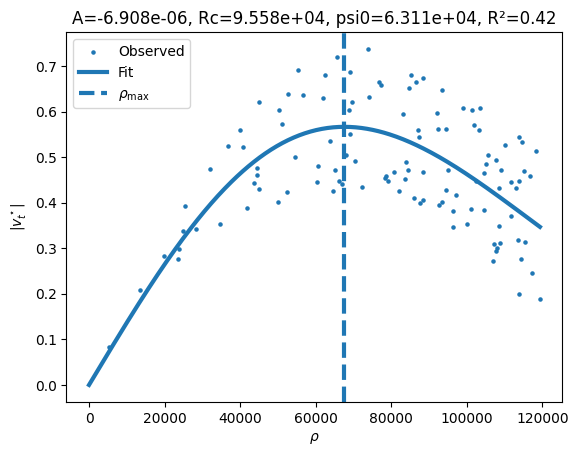

In [8]:
rho_outer = 120_000.0

xi0 = ds_sat.x.values.ravel()
yi0 = ds_sat.y.values.ravel()

Rc_opts, psi0_opts, A_opts = [], [], []
xyuv_rows = []

for k, data in df_res.iterrows():
    time = data.time

    ui0 = ds_sat.u.sel(time=time).values.ravel()
    vi0 = ds_sat.v.sel(time=time).values.ravel()

    xc, yc = float(data.xc), float(data.yc)
    Q = np.asarray(data.Q)
    A = float(data.A)
    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

    dx = xi0 - xc
    dy = yi0 - yc
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy

    outer = rho2 <= rho_outer**2
    xi_o, yi_o = xi0[outer], yi0[outer]
    ui_o, vi_o = ui0[outer], vi0[outer]
    dx_o, dy_o, rho2_o = dx[outer], dy[outer], rho2[outer]

    xyuv_rows.append(pd.DataFrame({
        "time": time, "core": "outer",
        "xi": xi_o, "yi": yi_o, "ui": ui_o, "vi": vi_o
    }))

    vt_o = tangential_velocity(xi_o, yi_o, ui_o, vi_o, xc, yc, Q)
    Qr_o = np.sqrt((q11*dx_o + q12*dy_o)**2 + (q12*dx_o + q22*dy_o)**2)

    sign_mask = (vt_o <= 0) if (A < 0) else (vt_o >= 0)
    rho2_f, Qr_f, vt_f = rho2_o[sign_mask], Qr_o[sign_mask], vt_o[sign_mask]

    Rc_opt, psi0_opt, A_opt = fit_psi_params(rho2_f, Qr_f, vt_f, A0=A, plot=(k == 10))
    Rc_opts.append(Rc_opt); psi0_opts.append(psi0_opt); A_opts.append(A_opt)

df_xyuv_o = pd.concat(xyuv_rows, ignore_index=True) if xyuv_rows else pd.DataFrame(
    columns=["time","core","xi","yi","ui","vi"]
)

df_xyuv = pd.concat([df_xyuv, df_xyuv_o], ignore_index=True)

df_res["Rc"] = Rc_opts
df_res["psi0"] = psi0_opts
df_res["A_opt"] = A_opts
df_res


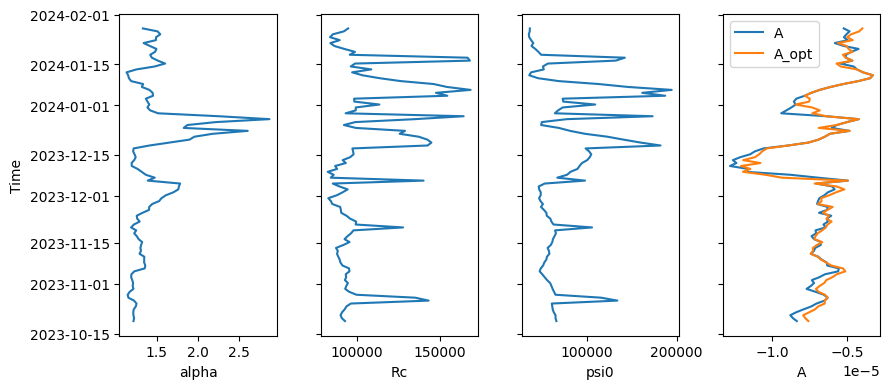

In [10]:
fig, axs = plt.subplots(1, 4, sharey=True, figsize=(9,4))

cols = ["alpha", "Rc", "psi0", "A"]

for ax, c in zip(axs, cols):
    ax.plot(df_res[c], df_res.time)
    ax.set_xlabel(c)

# overlay A_opt
axs[3].plot(df_res.A_opt, df_res.time)
axs[3].legend(["A", "A_opt"])

axs[0].set_ylabel("Time")

plt.tight_layout()


In [11]:
X = ds_sat.x.values
Y = ds_sat.y.values
nt = len(df_res)

U = np.empty((nt, X.shape[0], X.shape[1]))
V = np.empty((nt, X.shape[0], X.shape[1]))

for k in range(nt):
    data = df_res.iloc[k]

    dx = X - data.xc
    dy = Y - data.yc

    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]

    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
    fac = data.A_opt * np.exp(-rho2 / data.Rc**2)

    U[k] = -fac * (2*q12*dx + 2*q22*dy)
    V[k] =  fac * (2*q11*dx + 2*q12*dy)

mask = ds_sat.land_mask.values[None, :, :]   # (1, lat, lon)
U = np.where(mask, np.nan, U)
V = np.where(mask, np.nan, V)

ds_model = xr.Dataset(
    data_vars=dict(
        u=(("time","lat","lon"), U),
        v=(("time","lat","lon"), V),
    ),
    coords=dict(
        time=df_res.time.values,
        lat=ds_sat.lat.values,
        lon=ds_sat.lon.values,
        x=(("lat","lon"), X),
        y=(("lat","lon"), Y),
    ),
)

In [13]:
def plot__model(df_res, ds_sat, ds_model, df_xyuv, time=None, spac=1, scale=20,
                      xlim=(-410, 200), ylim=(-160, 260), out_thresh=False, plot_data=False):

    if time is None:
        time = ds_model.time.values[0]

    sat = ds_sat.sel(time=time, method="nearest")
    mod = ds_model.sel(time=time, method="nearest")
    data = df_res[df_res.time == time].iloc[0]

    X = sat.x.values / 1e3
    Y = sat.y.values / 1e3

    us, vs = sat.u.values, sat.v.values
    um, vm = mod.u.values, mod.v.values

    sp_s = np.hypot(us, vs)
    sp_m = np.hypot(um, vm)

    # ROI mask in km-space
    roi = (X >= xlim[0]) & (X <= xlim[1]) & (Y >= ylim[0]) & (Y <= ylim[1])

    sp_s_roi = np.where(roi, sp_s, np.nan)
    sp_m_roi = np.where(roi, sp_m, np.nan)

    # combine the two fields to determine colour scale
    vals = np.concatenate([sp_s_roi[roi], sp_m_roi[roi]])
    vmin, vmax = np.nanmin(vals), np.nanmax(vals)

    levels = np.linspace(vmin, vmax, 30)   # shared contour levels

    # ellipse contour uses meters for rho2, but plotted on km grid
    dx = sat.x.values - data.xc
    dy = sat.y.values - data.yc
    rho2 = data.Q[0,0]*dx**2 + 2*data.Q[1,0]*dx*dy + data.Q[1,1]*dy**2

    fig, axs = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True, constrained_layout=True)

    # ---- Satellite ----
    h0 = axs[0].contourf(X, Y, sp_s_roi, levels=levels, cmap="Blues_r")

    axs[0].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi[::spac,::spac], us[::spac,::spac], np.nan),
                  np.where(roi[::spac,::spac], vs[::spac,::spac], np.nan),
                  scale=scale)

    axs[0].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50)
    axs[0].contour(X, Y, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2) 
    if out_thresh:
        axs[0].contour(X, Y, rho2, levels=[120_000**2], colors="r", linewidths=2, linestyles='--')
    axs[0].plot(df_res.xc/1e3, df_res.yc/1e3, color="r", lw=.5)
    # if plot_data:
    #     df = df_xyuv.copy()
    #     df = df_xyuv[(df_xyuv.time==time)&(df_xyuv.core=='outer')]
    #     axs[1].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.002, color='g')
    #     df = df_xyuv[(df_xyuv.time==time)&(df_xyuv.core=='inner')]
    #     axs[1].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.002, color='m')
    axs[0].set_title("Satellite")
    axs[0].set_aspect("equal")

    # ---- Model ----
    h1 = axs[1].contourf(X, Y, sp_m_roi, levels=levels, cmap="Blues_r")
    if not plot_data:
        axs[1].quiver(X[::spac,::spac], Y[::spac,::spac],
                      np.where(roi[::spac,::spac], um[::spac,::spac], np.nan),
                      np.where(roi[::spac,::spac], vm[::spac,::spac], np.nan),
                      scale=scale)

    axs[1].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50)
    axs[1].contour(X, Y, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2)
    if out_thresh:
        axs[1].contour(X, Y, rho2, levels=[120_000**2], colors="r", linewidths=2, linestyles='--')
    if plot_data:
        df = df_xyuv.copy()
        df = df_xyuv[(df_xyuv.time==time)&(df_xyuv.core=='outer')]
        axs[1].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.002, color='g')
        df = df_xyuv[(df_xyuv.time==time)&(df_xyuv.core=='inner')]
        axs[1].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.002, color='m')
    axs[1].set_title("Model")
    axs[1].set_aspect("equal")

    gap = 20
    for ax in axs:
        ax.set_xlim(xlim[0]+gap, xlim[1]-gap)
        ax.set_ylim(ylim[0]+gap, ylim[1]-gap)
        ax.set_xlabel("x (km)")
    axs[0].set_ylabel("y (km)")

    fig.colorbar(h1, ax=axs, label="Speed (m/s)", fraction=0.03, pad=0.02)
    fig.suptitle(f"time ≈ {np.datetime_as_string(time, unit='m')}")
    plt.show()
    

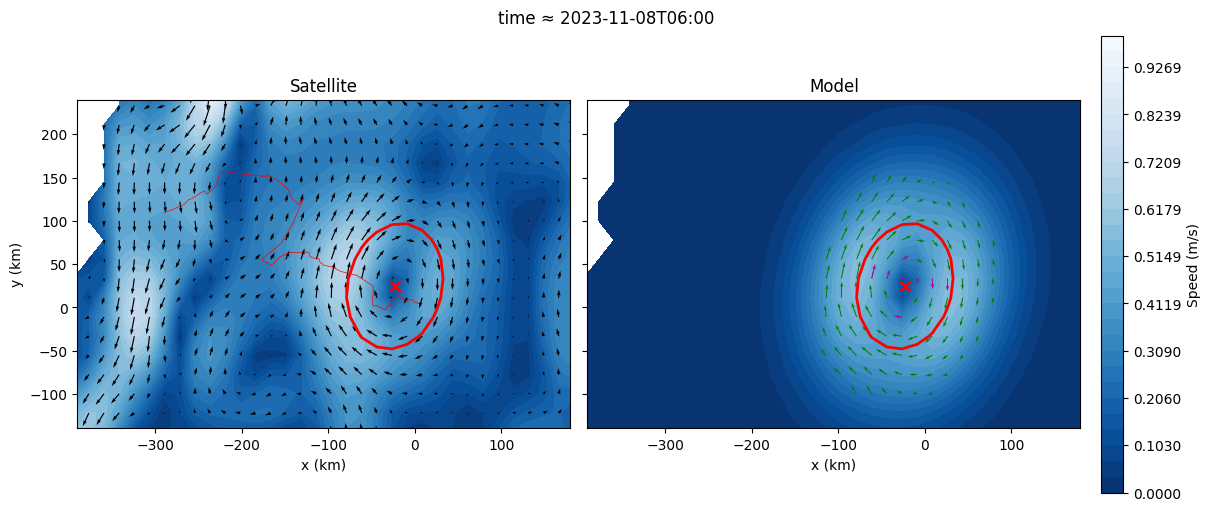

In [14]:
plot__model(df_res, ds_sat, ds_model, df_xyuv, time=df_res.time.values[20], spac=1, out_thresh=False, plot_data=True)
